# ***Edmentum Product Analyst***


## ***Step 1: Load Dataset***

In [2]:
import pandas as pd

df = pd.read_csv('/content/online_learning_engagement_dropout_risk.csv')

df.head()

,student_id,course_category,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent,device_type,dropout_risk
0,1,Design,14,17,51,7,60.42,14,23,Desktop,Low
1,2,AI & ML,8,26,1,10,77.25,33,29,Tablet,Medium
2,3,Business,6,26,24,1,93.46,23,82,Desktop,Low
3,4,AI & ML,5,99,12,7,69.77,32,92,Desktop,Low
4,5,AI & ML,13,150,97,3,89.48,40,34,Tablet,Low


# ***Step 2: Understand the Dataset***

In [3]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                2800 non-null   int64  
 1   course_category           2800 non-null   object 
 2   login_frequency_per_week  2800 non-null   int64  
 3   avg_session_minutes       2800 non-null   int64  
 4   course_progress_percent   2800 non-null   int64  
 5   assignments_completed     2800 non-null   int64  
 6   quiz_average_score        2800 non-null   float64
 7   forum_interactions        2800 non-null   int64  
 8   video_watch_percent       2800 non-null   int64  
 9   device_type               2800 non-null   object 
 10  dropout_risk              2800 non-null   object 
dtypes: float64(1), int64(7), object(3)
memory usage: 240.8+ KB


In [4]:
# Statistical summary
df.describe()

,student_id,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,7.498571,94.236786,50.601786,5.612857,70.130061,24.644286,60.263571
std,808.434702,4.032557,48.937770,29.157302,3.445816,17.395494,14.642357,23.583951
min,1.000000,1.000000,10.000000,0.000000,0.000000,40.010000,0.000000,20.000000
25%,700.750000,4.000000,52.000000,25.000000,3.000000,55.110000,12.000000,39.000000
50%,1400.500000,8.000000,94.000000,52.000000,6.000000,69.910000,24.000000,60.000000
75%,2100.250000,11.000000,136.000000,76.000000,9.000000,85.515000,37.000000,81.000000
max,2800.000000,14.000000,179.000000,100.000000,11.000000,99.980000,49.000000,100.000000


In [5]:
# Missing values
df.isnull().sum()

,0
student_id,0
course_category,0
login_frequency_per_week,0
avg_session_minutes,0
course_progress_percent,0
assignments_completed,0
quiz_average_score,0
forum_interactions,0
video_watch_percent,0
device_type,0


In [6]:
# Column names
df.columns

Index(['student_id', 'course_category', 'login_frequency_per_week',
       'avg_session_minutes', 'course_progress_percent',
       'assignments_completed', 'quiz_average_score', 'forum_interactions',
       'video_watch_percent', 'device_type', 'dropout_risk'],
      dtype='object')

In [8]:
# Dropout distribution
df['dropout_risk'].value_counts(normalize=True) * 100

,proportion
dropout_risk,
Low,48.571429
Medium,30.250000
High,21.178571


In [9]:
# Correlation analysis
df.corr(numeric_only=True)

,student_id,login_frequency_per_week,avg_session_minutes,course_progress_percent,assignments_completed,quiz_average_score,forum_interactions,video_watch_percent
student_id,1.000000,0.015067,-0.012528,0.022613,0.001923,0.010288,0.008734,-0.034515
login_frequency_per_week,0.015067,1.000000,-0.006062,0.001273,0.024515,0.004054,0.002563,-0.007051
avg_session_minutes,-0.012528,-0.006062,1.000000,0.021867,-0.011732,0.001955,0.029169,0.010164
course_progress_percent,0.022613,0.001273,0.021867,1.000000,-0.056236,0.022881,-0.027161,-0.003308
assignments_completed,0.001923,0.024515,-0.011732,-0.056236,1.000000,-0.020079,0.018144,0.020842
quiz_average_score,0.010288,0.004054,0.001955,0.022881,-0.020079,1.000000,0.009843,-0.025766
forum_interactions,0.008734,0.002563,0.029169,-0.027161,0.018144,0.009843,1.000000,0.010677
video_watch_percent,-0.034515,-0.007051,0.010164,-0.003308,0.020842,-0.025766,0.010677,1.000000


In [12]:
# Top factors affecting dropout
import seaborn as sns
import matplotlib.pyplot as plt

# Map dropout_risk to numerical values
dropout_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['dropout_risk_numeric'] = df['dropout_risk'].map(dropout_mapping)

corr = df.corr(numeric_only=True)['dropout_risk_numeric'].sort_values(ascending=False)
print(corr)

# Drop the temporary numeric column if not needed later
df.drop(columns=['dropout_risk_numeric'], inplace=True)

dropout_risk_numeric        1.000000
course_progress_percent     0.037307
quiz_average_score          0.028904
student_id                  0.009573
assignments_completed       0.004344
avg_session_minutes        -0.003982
login_frequency_per_week   -0.010845
video_watch_percent        -0.010901
forum_interactions         -0.018362
Name: dropout_risk_numeric, dtype: float64


# ***Step 3: Product Metric — Dropout Distribution***

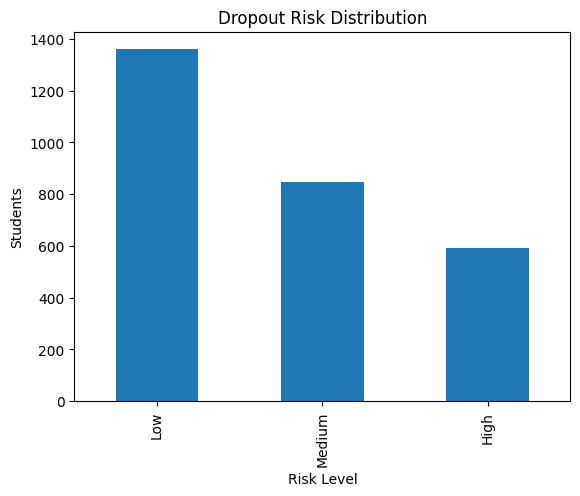

In [13]:
import matplotlib.pyplot as plt

dropout = df['dropout_risk'].value_counts()

dropout.plot(kind='bar')

plt.title('Dropout Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Students')
plt.show()

# ***Step 4: Engagement Analysis***

In [14]:
df.groupby('dropout_risk')['login_frequency_per_week'].mean().sort_values()

,login_frequency_per_week
dropout_risk,
High,7.404722
Medium,7.515939
Low,7.528676


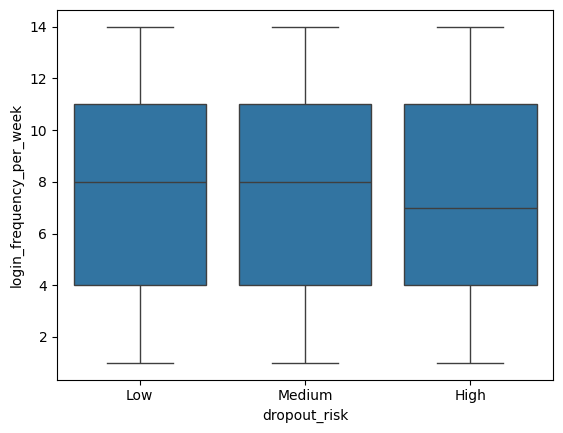

In [15]:
import seaborn as sns

sns.boxplot(
    data=df,
    x='dropout_risk',
    y='login_frequency_per_week'
)

plt.show()

# ***Step 5: Session Duration Analysis***

In [16]:
df.groupby('dropout_risk')['avg_session_minutes'].mean()

,avg_session_minutes
dropout_risk,
High,93.583474
Low,94.268382
Medium,94.643447


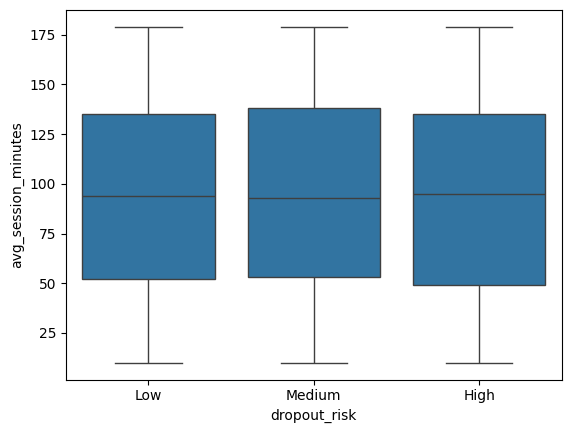

In [17]:
sns.boxplot(
    data=df,
    x='dropout_risk',
    y='avg_session_minutes'
)

plt.show()

# ***Step 6: Course Progress Analysis***

In [18]:
df.groupby('dropout_risk')['course_progress_percent'].mean()

,course_progress_percent
dropout_risk,
High,53.195616
Low,49.966176
Medium,49.806375


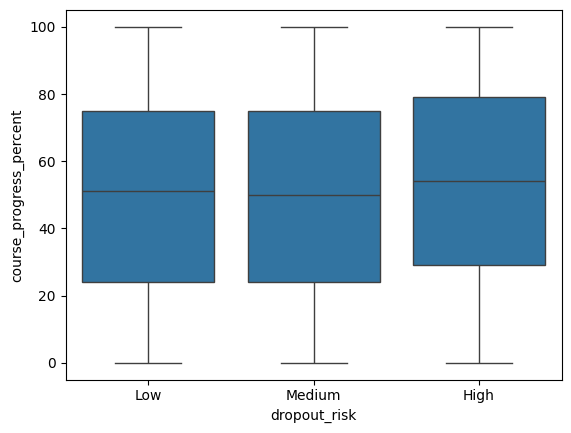

In [19]:
sns.boxplot(
    data=df,
    x='dropout_risk',
    y='course_progress_percent'
)

plt.show()

#***Step 7: Assignment Completion***

In [20]:
df.groupby('dropout_risk')['assignments_completed'].mean()

,assignments_completed
dropout_risk,
High,5.708263
Low,5.630147
Medium,5.518300


# ***Step 8: Quiz Performance***

In [21]:
df.groupby('dropout_risk')['quiz_average_score'].mean()

,quiz_average_score
dropout_risk,
High,71.009191
Low,69.696831
Medium,70.210189


# ***Step 9: Correlation Analysis***

In [22]:
risk_map = {
    'Low':0,
    'Medium':1,
    'High':2
}

df['risk_score'] = df['dropout_risk'].map(risk_map)

In [23]:
corr = df.corr(numeric_only=True)

corr['risk_score'].sort_values(ascending=False)

,risk_score
risk_score,1.000000
course_progress_percent,0.037307
quiz_average_score,0.028904
student_id,0.009573
assignments_completed,0.004344
avg_session_minutes,-0.003982
login_frequency_per_week,-0.010845
video_watch_percent,-0.010901
forum_interactions,-0.018362


# ***Step 10: Course Category Analysis***

In [24]:
category = pd.crosstab(
    df['course_category'],
    df['dropout_risk']
)

category

dropout_risk,High,Low,Medium
course_category,,,
AI & ML,110,293,164
Business,112,263,153
Data Science,133,276,158
Design,139,261,181
Programming,99,267,191


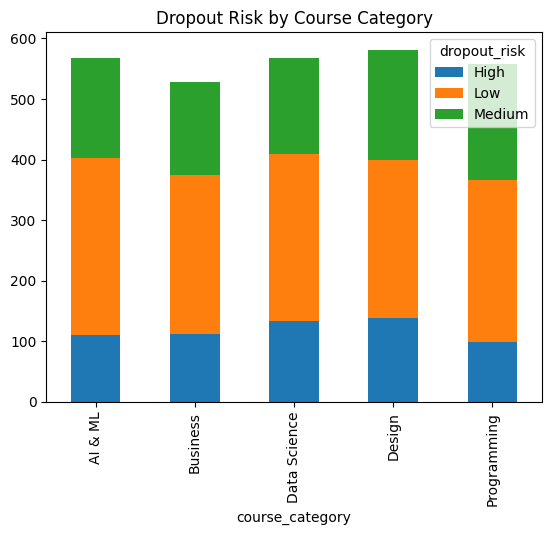

In [25]:
category.plot(kind='bar', stacked=True)

plt.title('Dropout Risk by Course Category')
plt.show()

# ***Step 11: Device Analysis***

In [27]:
device = pd.crosstab(
    df['device_type'],
    df['dropout_risk']
)

device

dropout_risk,High,Low,Medium
device_type,,,
Desktop,208,457,292
Mobile,196,465,258
Tablet,189,438,297


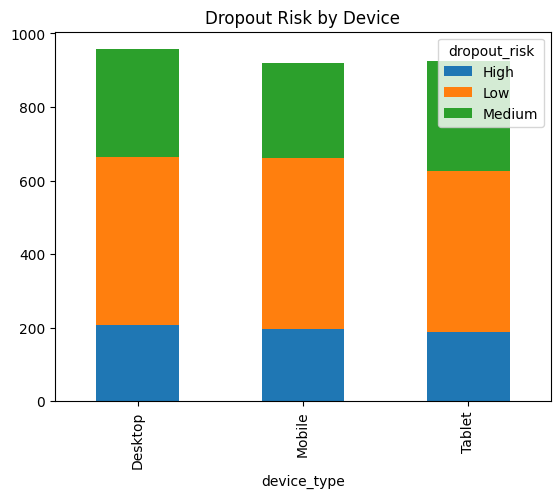

In [28]:
device.plot(kind='bar', stacked=True)

plt.title('Dropout Risk by Device')
plt.show()